<a href="https://colab.research.google.com/github/Himanshuxone/base-ai/blob/main/train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os
words = open('name.txt', 'r').read().splitlines()
#  printing the next character for each charactor under the pivot
b = {}
for w in words:
    # create a biagram of start and end for the given string
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1
# sorted(b.items(), key=lambda kv: -kv[1])

In [5]:
import torch

In [6]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [7]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0

In [8]:
for w in words:
    # create a biagram of start and end for the given string
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

In [ ]:
itos = {i:s for s,i in stoi.items()}

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

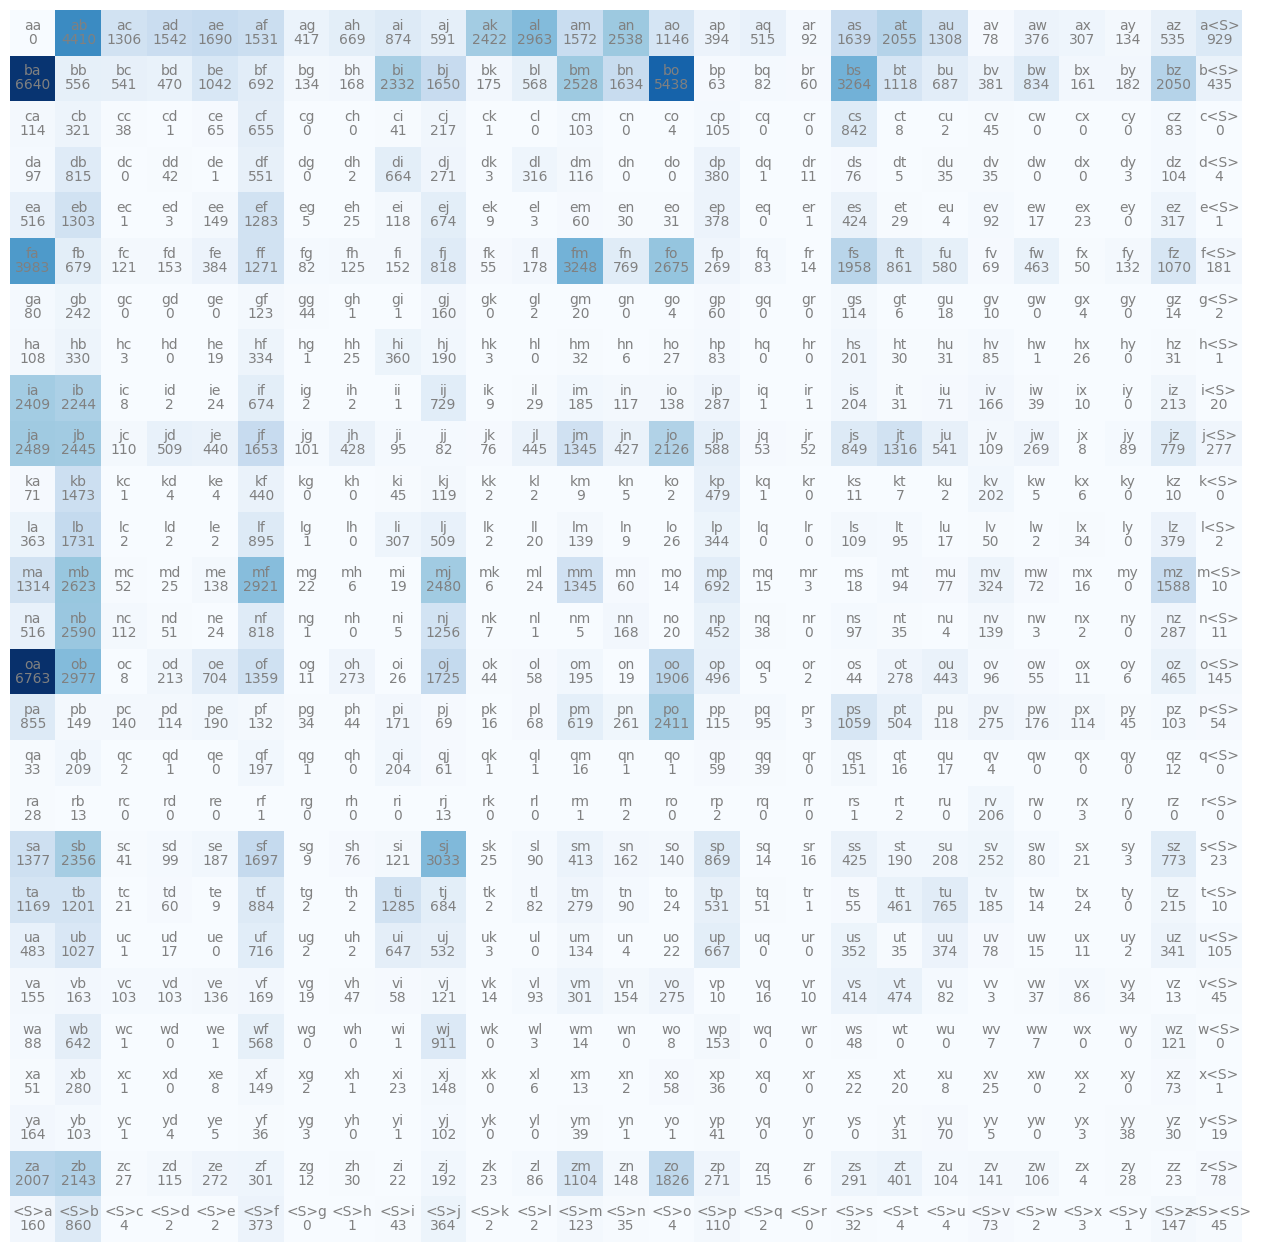

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
  for j in range(27):
    chstr = itos[i]+itos[j]
    plt.text(j,i, chstr, ha='center', va='bottom', color='gray')
    plt.text(j,i, N[i,j].item(), ha='center', va='top', color='gray')
plt.axis('off')

In [11]:
# creating a training set of biagrams (x,y):
# creating a list to store the first character and the next one following character
xs, ys = [], []
for w in words[:1]:
    # create a biagram of start and end for the given string
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(ch1, ch2)
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)

. e
e m
m m
m a
a .
